## Imports

In [375]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "data" / "dblp-1.csv").exists():
    ROOT_DIR = ROOT_DIR / "project"
DATA_DIR = ROOT_DIR / "data"

## Helper Functions

In [376]:
# helper function to load json
def load_lookup(path):
    with open(path) as f:
        raw = json.load(f)
    df_lu = pd.DataFrame(raw) 
    return dict(zip(df_lu["id"], df_lu["name"]))

def check_duplicates(df, exclude=None, mappings=None):
    cols = [c for c in df.columns if c not in (exclude or [])]
    rows = []
    for col in cols:
        series = df[col]
        if mappings and col in mappings:
            series = series.map(mappings[col])
        dupes = series.duplicated(keep=False).sum()
        rows.append({"column": col, "duplicate_count": dupes, "duplicate_%": round(100 * dupes / len(df), 1)})
    return pd.DataFrame(rows).set_index("column").sort_values("duplicate_count", ascending=False)

## Data Loading
Load the four DBLP shards, pair files (train/val/test), and JSON lookup tables.

In [377]:
dblp_1_path = DATA_DIR / "dblp-1.csv"
dblp_2_path = DATA_DIR / "dblp-2.csv"
dblp_3_path = DATA_DIR / "dblp-3.csv"
dblp_4_path = DATA_DIR / "dblp-4.csv"

dblp_1 = pd.read_csv(dblp_1_path, index_col=0)
dblp_2 = pd.read_csv(dblp_2_path, index_col=0)
dblp_3 = pd.read_csv(dblp_3_path, index_col=0)
dblp_4 = pd.read_csv(dblp_4_path, index_col=0)

print(dblp_1.shape)
print(dblp_2.shape)
print(dblp_3.shape)
print(dblp_4.shape)

(4279, 15)
(4301, 15)
(4329, 15)
(4256, 15)


In [378]:
all_match = dblp_1.columns.equals(dblp_2.columns) and \
            dblp_2.columns.equals(dblp_3.columns) and \
            dblp_3.columns.equals(dblp_4.columns)

print(all_match)

True


The structure of columns match all `dblp` files. Hence, we concat those `.csv` files

In [379]:
df = pd.concat([dblp_1, dblp_2, dblp_3, dblp_4], ignore_index=True)

In [380]:
# df holds original columns only; all derived/computed columns go here
df_extra = pd.DataFrame(index=df.index)

In [381]:
ptype        = load_lookup(DATA_DIR / "ptype.json")
pjournal     = load_lookup(DATA_DIR / "pjournal.json")
pjournalfull = load_lookup(DATA_DIR / "pjournalfull.json")
pbooktitle   = load_lookup(DATA_DIR / "pbooktitle.json")
pbooktitlefull = load_lookup(DATA_DIR / "pbooktitlefull.json")

id_mappings = {
    "ptype_id":          ptype,
    "pjournal_id":       pjournal,
    "pbooktitle_id":     pbooktitle,
    "pjournalfull_id":   pjournalfull,
    "pbooktitlefull_id": pbooktitlefull,
}

for name, m in [("ptype", ptype), ("pjournal", pjournal),
                ("pjournalfull", pjournalfull), ("pbooktitle", pbooktitle),
                ("pbooktitlefull", pbooktitlefull)]:
    print(f"{name}: {len(m)} rows")

ptype: 9 rows
pjournal: 718 rows
pjournalfull: 90 rows
pbooktitle: 2720 rows
pbooktitlefull: 1084 rows


## Basic Statistics 
Get a quick overview of dtypes, non-null counts, numeric summaries, and a random sample.

In [382]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17165 entries, 0 to 17164
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pauthor            17165 non-null  object 
 1   peditor            0 non-null      float64
 2   ptitle             17165 non-null  object 
 3   pyear              17165 non-null  int64  
 4   paddress           0 non-null      float64
 5   ppublisher         17 non-null     object 
 6   pseries            5 non-null      object 
 7   pid                17165 non-null  int64  
 8   pkey               17165 non-null  object 
 9   ptype_id           17165 non-null  int64  
 10  pjournal_id        17165 non-null  int64  
 11  pbooktitle_id      17165 non-null  int64  
 12  pjournalfull_id    17165 non-null  int64  
 13  pbooktitlefull_id  17165 non-null  int64  
 14  partition          17165 non-null  int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 7.2 MB


In [383]:
df.sample(5, random_state=42)

,pauthor,peditor,ptitle,pyear,paddress,ppublisher,pseries,pid,pkey,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
3706,Frank Suits|Michael Pitman|Jed W. Pitera|Willi...,NaN,Overview of molecular dynamics techniques and ...,-2005,NaN,NaN,NaN,2002783,journals/ibmrd/SuitsPPSG05,3,0,5,0,5,1
2518,Yong Liu|David J. Hill 0002|Alejandro Rodrígue...,NaN,Near-real-time precipitation virtual sensor us...,2008,NaN,NaN,NaN,273337,conf/gis/LiuHRMKFMM08,2,0,5,0,5,1
5843,Yan Song|Guo-Jun Qi|Xian-Sheng Hua|Li-Rong Dai...,NaN,Video Annotation by Active Learning and Semi-S...,2006,NaN,NaN,NaN,388674,conf/icmcs/SongQHDW06,2,0,0,0,0,2
11843,Yiyang Pei|Ying-Chang Liang|Kah Chan Teh|Kwok ...,NaN,How much time is needed for wideband spectrum ...,2009,NaN,NaN,NaN,2354661,journals/twc/PeiLTL09,0,162,5,162,5,3
11847,Hajime Ohyanagi|Tsuyoshi Tanaka|Hiroaki Sakai|...,NaN,The Rice Annotation Project Database (RAP-DB):...,2006,NaN,NaN,NaN,2159200,journals/nar/OhyanagiTSSYHFANIIIGS06,3,45,5,45,5,3


In [384]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].describe()

,peditor,pyear,paddress,pid,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
count,0.0,17165.000000,0.0,1.716500e+04,17165.000000,17165.000000,17165.000000,17165.000000,17165.000000,17165.000000
mean,NaN,359.046140,NaN,1.062491e+06,1.815264,64.476959,486.942208,64.476959,486.942208,2.498806
std,NaN,1971.505007,NaN,8.352665e+05,1.256148,137.321095,695.529516,137.321095,695.529516,1.115588
min,NaN,-2011.000000,NaN,1.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,-2004.000000,NaN,3.568410e+05,1.000000,0.000000,5.000000,0.000000,5.000000,2.000000
50%,NaN,1999.000000,NaN,7.230580e+05,2.000000,0.000000,68.000000,0.000000,68.000000,3.000000
75%,NaN,2007.000000,NaN,2.013849e+06,3.000000,45.000000,794.000000,45.000000,794.000000,3.000000
max,NaN,2011.000000,NaN,2.434225e+06,8.000000,717.000000,2719.000000,717.000000,2719.000000,4.000000


## Missing Values: `paddress`, `ppublisher`, `pseries`, `peditor`
List NaN counts, empty strings, and total missing rate per column.

In [385]:
is_null = df.isnull()
is_empty = df.astype(str).eq("") & ~is_null
is_missing = is_null | is_empty

missing = pd.DataFrame(
    {
    "null_count" : is_null.sum(),
    "empty_str" : is_empty.sum(),
    "total_missing" : is_missing.sum(),
    "missing_pct" : is_missing.mean().mul(100).round(1)
    }
).sort_values("missing_pct", ascending=False)

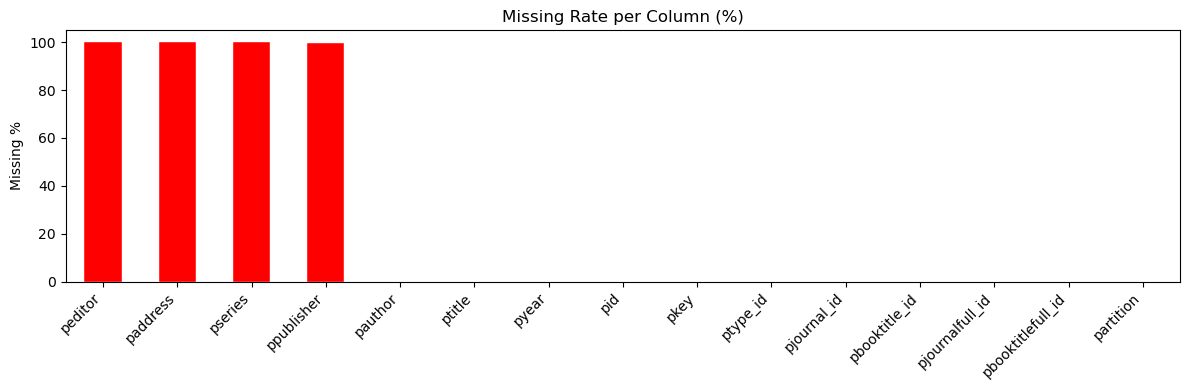

In [386]:
fig, ax = plt.subplots(figsize=(12, 4))

missing["missing_pct"].plot(kind="bar", ax=ax, color='red',edgecolor="white", linewidth=0.3)

ax.set_title("Missing Rate per Column (%)")
ax.set_ylabel("Missing %")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Non-Mising Str Columns: `pauthor`, `ptitle`
Inspect title and author length distributions, detect outliers, and audit whitespace/NaN patterns.

Since `pkey` stores a different format string than `ptitle` or `pauthor`, we only look at character distributions of the latter two.

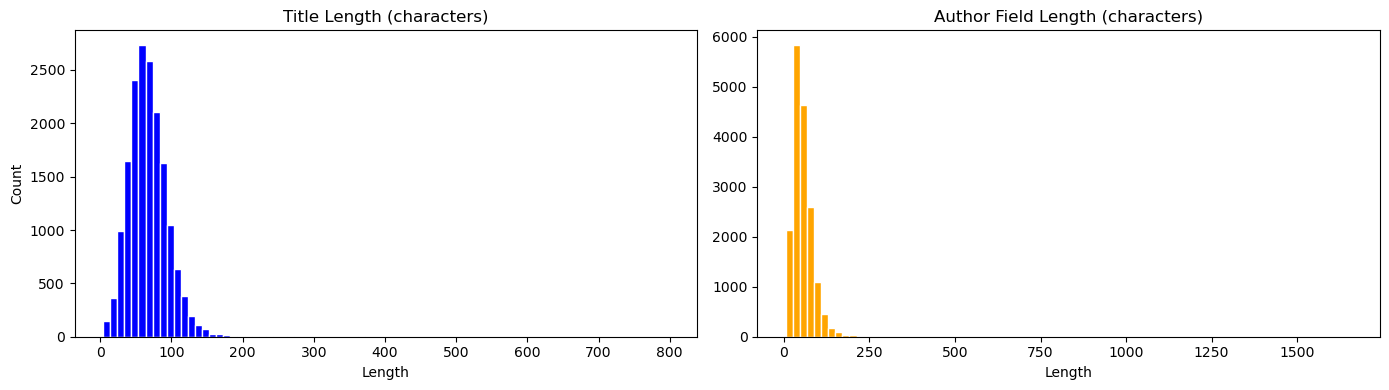

In [387]:
df_extra["title_len"]  = df["ptitle"].str.len()
df_extra["author_len"] = df["pauthor"].str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(df_extra["title_len"], bins=80, color="blue", edgecolor="white")
ax1.set_title("Title Length (characters)")
ax1.set_xlabel("Length")
ax1.set_ylabel("Count")

ax2.hist(df_extra["author_len"].dropna(), bins=80, edgecolor="white", color="orange")
ax2.set_title("Author Field Length (characters)")
ax2.set_xlabel("Length")
plt.tight_layout()
plt.show()

Outliers of `ptitle` column

In [388]:
short_titles = df[df_extra["title_len"] < 10][["ptitle", "pkey"]].join(df_extra["title_len"])
long_titles  = df[df_extra["title_len"] > 300][["ptitle", "pkey"]].join(df_extra["title_len"])
print(f"Titles shorter than 10 chars: {len(short_titles)}")
display(short_titles.head(10))
print(f"\nTitles longer than 300 chars: {len(long_titles)}")
display(long_titles.head(10))

Titles shorter than 10 chars: 35


,ptitle,pkey,title_len
1035,J. Smit,conf/eurosam/Smit79,7
1996,Preface.,journals/tcs/HofmannRP99,8
2100,Modulus.,reference/crypt/Contini05c,8
2172,Preface.,journals/entcs/HappeB10,8
4111,Preface.,journals/speech/CutlerCL10,8
4211,CAD.,conf/dagstuhl/RollerH93,4
4227,Preface.,journals/eswa/AlvaradoCC04,8
4234,News.,journals/ieeesp/StoneAA04,5
4280,Z. Sun,conf/prozess/Sun88,6
5265,J. Y. Kim,conf/premi/Kim05,9



Titles longer than 300 chars: 13


,ptitle,pkey,title_len
506,Luc Moreau|Simon Miles|Carole A. Goble|R. Mark...,conf/ccgrid/MoreauMGGDAACRFGGGLLLLMOPPRRRRSSSW...,446
2218,Donna Karolchik|Robert M. Kuhn|Robert Baertsch...,journals/nar/KarolchikKBBCDGHHHKMPPRRRSSTTWZHK08,367
2221,Paul Flicek|B. L. Aken|Kathryn Beal|Benoit Bal...,journals/nar/FlicekABBCCCCCCDDEFFGHHHHHJJKKKKL...,799
5095,Francesco Pappalardo|Mark D. Halling-Brown|Nic...,journals/bib/PappalardoHRZAEPDPPMCRSMCBLBMLBB09,363
7033,Peter Fankhauser|Norbert Fuhr|Jens Hartmann|An...,conf/gi/FankhauserFHJKKKKL0MOOPRRSBSSSSSVWW05,390
8570,Robert M. Kuhn|Donna Karolchik|Ann S. Zweig|He...,journals/nar/KuhnKZTTTSSSSRRRPPHHHDCBBBHK07,381
9669,Gabriele Garzoglio|Ian Alderman|Mine Altunay|R...,journals/grid/GarzoglioAAABCCDFFGHHKJLMPSSSSSVW09,365
10028,Kieron Messer|Josef Kittler|Mohammad Sadeghi|S...,conf/avbpa/MesserKSMMBCSCVSPKKPKTADM03,302
10294,Piotr D. Adamczyk|Kevin Hamilton|Alan Chamberl...,journals/dsonline/AdamczykHCBTOHLSKLSKNAMARPL07,302
10876,John H. Edmondson|Paul I. Rubinfeld|Peter J. B...,journals/dtj/EdmondsonRBBBCCDDFJMMPRSTW95,326


We notice that oftentimes titles contain author names. For long outliers, authors are separated by `|`. Lets see whether this is the case in `pauthor`.

In [389]:
long_auhtors = df[df_extra["author_len"] > 200][["pauthor", "pkey"]].join(df_extra["author_len"])
print(f"Author inputs longer than 200 chars: {len(long_auhtors)}")
display(long_auhtors.head(10))

Author inputs longer than 200 chars: 83


,pauthor,pkey,author_len
29,Matthias Fuchs|Christoph Borst|Paolo Robuffo G...,conf/icra/FuchsBGBKLGSPKBSWH09,208
208,Ion-Florin Talos|Lauren O'Donnell|Carl-Fredrik...,conf/miccai/TalosOWWWYPGMMRGBJK03,253
266,Robert L. Melcher|Paul M. Alt|Derek B. Dove|Th...,journals/ibmrd/MelcherADCCDEHLNOPRSSSTUY98,305
402,Sabine Lehmann|Stephan Oepen|Sylvie Regnier-Pr...,journals/corr/cmp-lg-9607018,205
437,Michael Bedford Taylor|Jason Sungtae Kim|Jason...,journals/micro/TaylorKMWGGHJLLMSSSSFAA02,267
670,Leming M. Shi|Weida Tong|Hong Fang|Uwe Scherf|...,journals/bmcbi/ShiTFSHPFGGSHFXPHXPCC05,247
1055,Alessandro Bozzon|Marco Brambilla|Piero Frater...,conf/sigir/BozzonBFNDMNPAPLZBWC09,235
1070,Pedro Santos|André Stork|Thomas Gierlinger|Ala...,conf/hci/SantosSGPAJBJPWCABPHM07,236
1714,N. Brook|A. Bogdanchikov|A. Buckley|Joel Closi...,journals/corr/cs-DC-0306060,455
1825,Periklis Andritsos|Ronald Fagin|Ariel Fuxman|L...,journals/debu/AndritsosFFHHHKMNPVVY02,215


Lets look into author counts distribution:

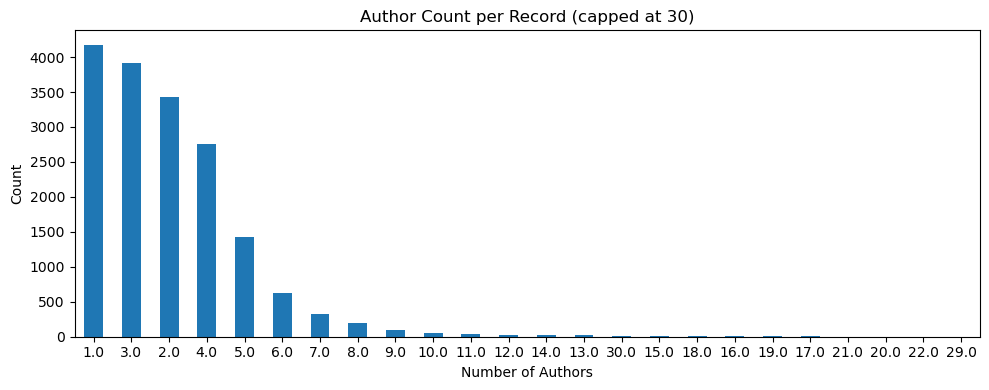

In [390]:
df_extra["author_count"] = df["pauthor"].str.count(r"\|") + 1
df_extra.loc[df["pauthor"].isnull(), "author_count"] = np.nan

fig, ax = plt.subplots(figsize=(10, 4))
# since distribution has a long tail, lets look into top 30
df_extra["author_count"].dropna().clip(upper=30).value_counts().plot(kind="bar", ax=ax)
ax.set_title("Author Count per Record (capped at 30)")
ax.set_xlabel("Number of Authors")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Publication Type: `ptype_id`
We examine raw `ptype_id` frequencies and detect duplicate names.

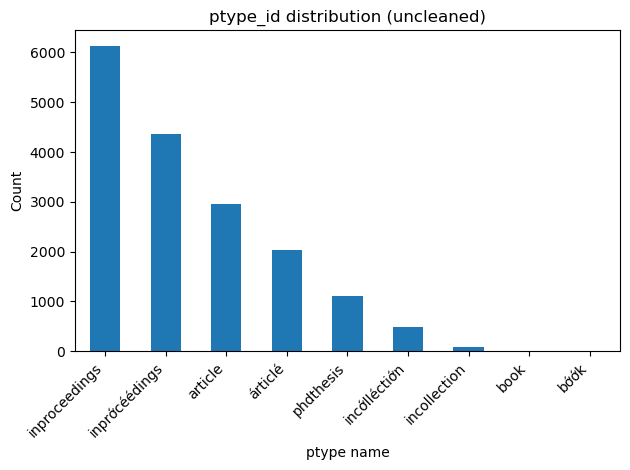

In [391]:
ptype_counts = df["ptype_id"].value_counts(dropna=False)
ptype_named  = ptype_counts.rename(index=ptype)

fig, ax = plt.subplots()
ptype_named.plot(kind="bar", ax=ax)
ax.set_title("ptype_id distribution (uncleaned)")
ax.set_xlabel("ptype name")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [392]:
print("All ptype.json entries:")
for id_, name in sorted(ptype.items()):
    print(f"  id={id_:2d}  name={repr(name)}")

All ptype.json entries:
  id= 0  name='árticlé'
  id= 1  name='inproceedings'
  id= 2  name='inprớcéédings'
  id= 3  name='article'
  id= 4  name='phdthesis'
  id= 5  name='incớlléctiớn'
  id= 6  name='incollection'
  id= 7  name='bớớk'
  id= 8  name='book'


## `pkey` Structure Analysis
We parse the `pkey` field to extract prefixes and conference names

In [393]:
df_extra["pkey_prefix"]     = df["pkey"].str.split("/").str[0]
df_extra["pkey_conference"] = df["pkey"].str.split("/").str[1]

In [394]:
print(df_extra["pkey_prefix"].value_counts())

pkey_prefix
conf         10954
journals      6082
series          47
reference       42
books           28
tr              11
phd              1
Name: count, dtype: int64


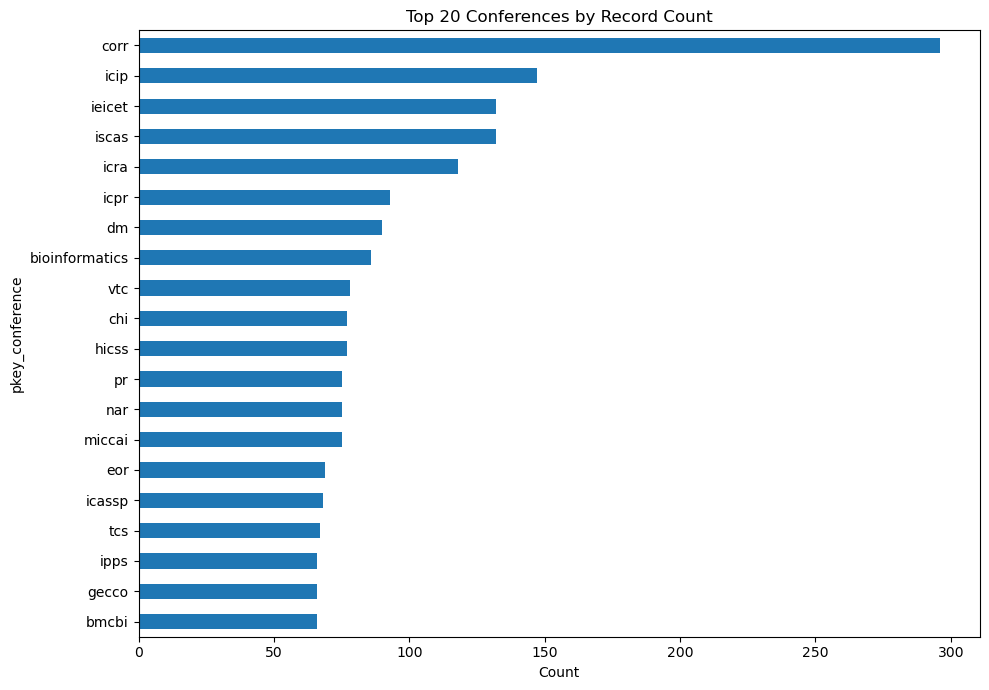

In [395]:
top_conference = df_extra["pkey_conference"].value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top_conference.plot(kind="barh", ax=ax)
ax.set_title("Top 20 Conferences by Record Count")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

In [396]:
# 6b — Cross-tabulate pkey_prefix vs ptype_canonical
crosstab = pd.crosstab(
    df_extra["pkey_prefix"],
    df["ptype_id"].map(ptype)
)
print("pkey_prefix vs ptype_canonical:")
display(crosstab)

pkey_prefix vs ptype_canonical:


ptype_id,article,book,bớớk,incollection,incớlléctiớn,inproceedings,inprớcéédings,phdthesis,árticlé
pkey_prefix,,,,,,,,,
books,0,4,0,17,4,0,3,0,0
conf,0,0,2,3,123,6014,3215,1107,490
journals,2944,1,0,0,351,123,1129,1,1533
phd,0,0,0,0,0,0,0,1,0
reference,0,0,0,29,6,0,5,0,2
series,0,2,2,30,7,0,5,0,1
tr,8,0,0,0,0,1,1,0,1


## Year Distribution `pyear`
Identify and quantify negative `pyear` values, visualise raw vs corrected distributions.

In [397]:
n_neg = (df["pyear"] < 0).sum()
n_pos = (df["pyear"] >= 0).sum()
print(f"Negative pyear values: {n_neg} ({100*n_neg/len(df):.1f}%)")
print(f"Non-negative pyear values: {n_pos}")
print("\nNegative year value_counts:")
print(df.loc[df["pyear"] < 0, "pyear"].value_counts().head(20))

Negative pyear values: 7045 (41.0%)
Non-negative pyear values: 10120

Negative year value_counts:
pyear
-2009    833
-2008    782
-2007    703
-2010    639
-2006    632
-2005    593
-2004    469
-2003    407
-2002    278
-2001    208
-2000    200
-1999    174
-1997    156
-1998    133
-1996    111
-1994     91
-1993     90
-1995     88
-1992     69
-1990     55
Name: count, dtype: int64


`pyear` distribution

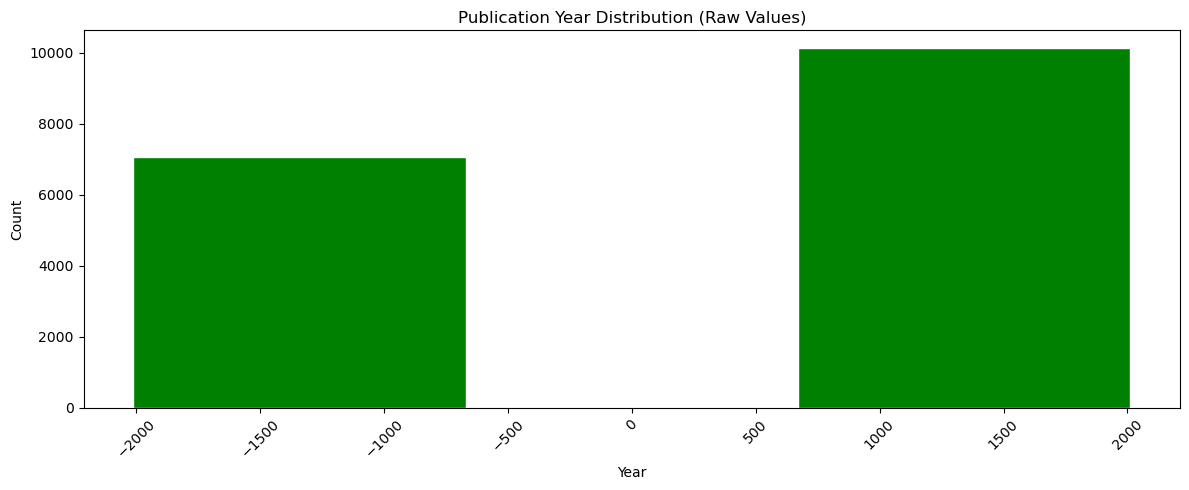

In [398]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df["pyear"].dropna(), bins=3, edgecolor="white", color="green")
ax.set_title("Publication Year Distribution (Raw Values)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Lets convert `pyear` into absolute values

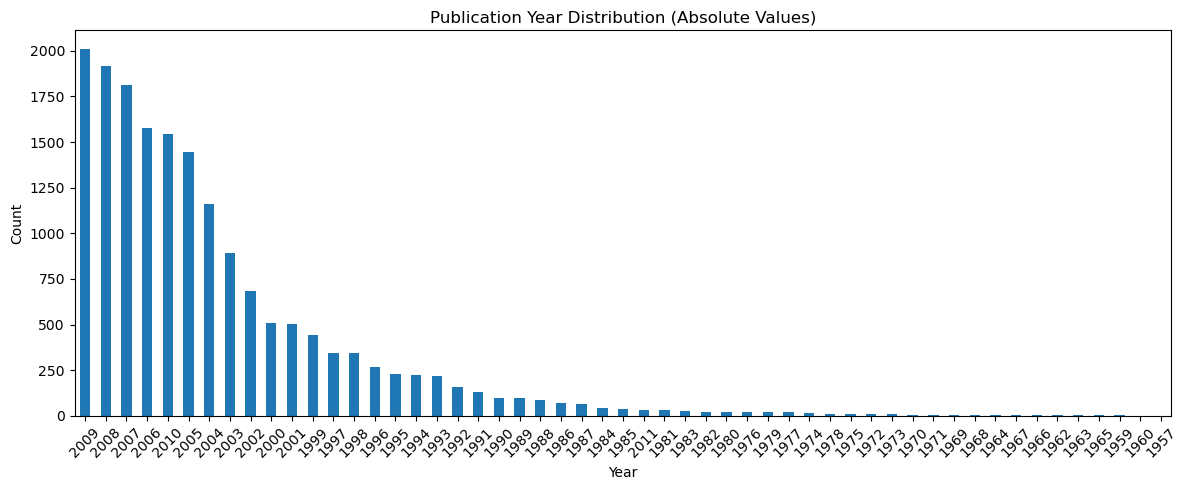

In [399]:
fig, ax = plt.subplots(figsize=(12, 5))
df["pyear"].abs().value_counts(dropna=False).plot(kind="bar", ax=ax)
ax.set_title("Publication Year Distribution (Absolute Values)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Journal & Booktitle Distributions: `pjournal_id` & `pbooktitle_id`
Resolve integer IDs to human-readable names and inspect top values.

<Axes: ylabel='pjournal_id'>

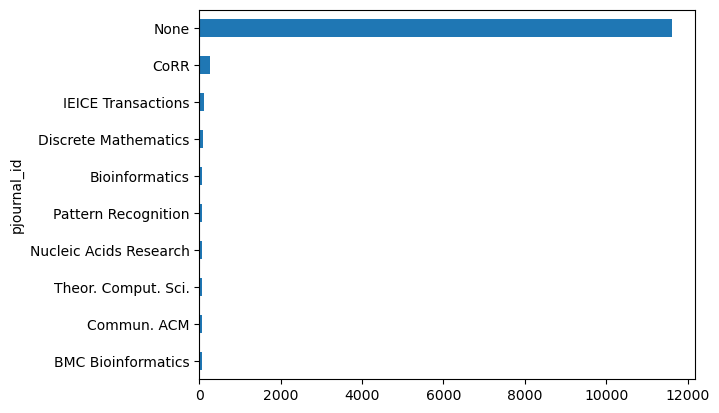

In [400]:
df["pjournal_id"].map(pjournal).value_counts(dropna=False).head(10).sort_values().plot(kind="barh")

<Axes: ylabel='pbooktitle_id'>

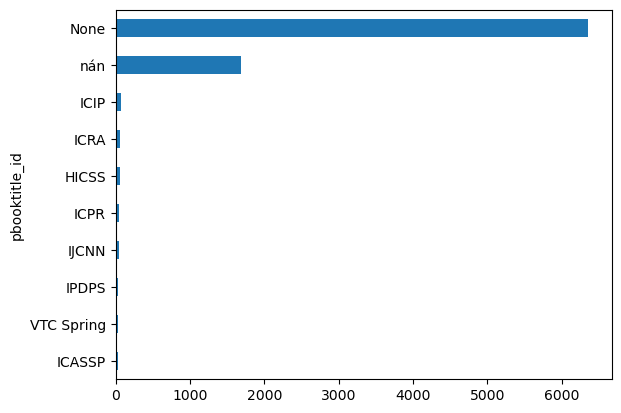

In [401]:
df["pbooktitle_id"].map(pbooktitle).value_counts(dropna=False).head(10).sort_values().plot(kind="barh")

## Journal Full & Booktitle Full Distributions: `pjournalfull_id` & `pbooktitlefull_id`

<Axes: ylabel='pjournalfull_id'>

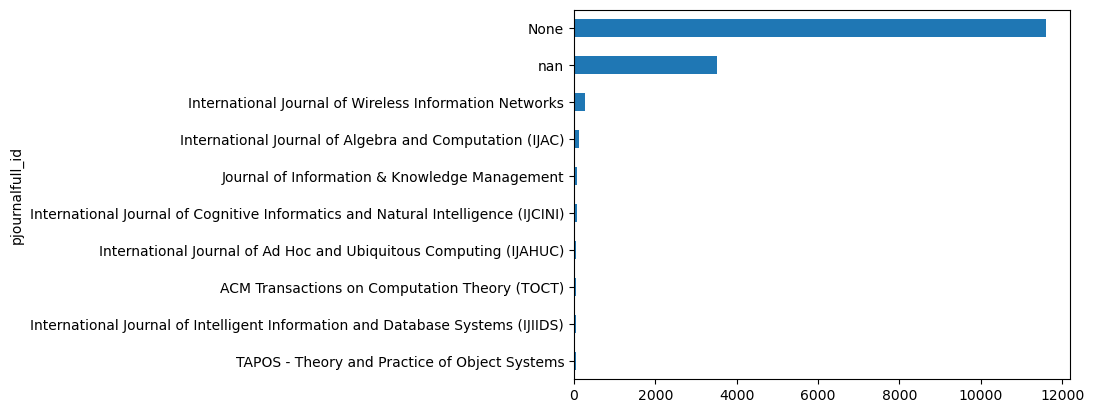

In [402]:
df["pjournalfull_id"].map(pjournalfull).value_counts(dropna=False).head(10).sort_values().plot(kind="barh")

<Axes: ylabel='pbooktitlefull_id'>

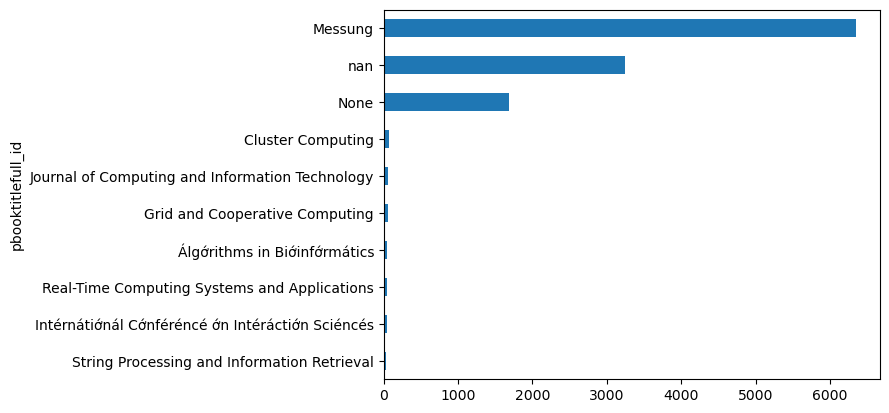

In [403]:
df["pbooktitlefull_id"].map(pbooktitlefull).value_counts(dropna=False).head(10).sort_values().plot(kind="barh")

## Duplicate Detection in Raw Records
Check for exact row duplicates and field-level uniqueness issues.

In [404]:
# 11a — Exact row duplicates
n_full_dups = df.duplicated().sum()
print(f"Exact row duplicates: {n_full_dups}")

Exact row duplicates: 0


In [405]:
display(check_duplicates(df, exclude=["peditor", "paddress"], mappings=id_mappings))

,duplicate_count,duplicate_%
column,,
ptype_id,17165,100.0
partition,17165,100.0
pjournalfull_id,17162,100.0
ppublisher,17161,100.0
pseries,17160,100.0
pyear,17153,99.9
pjournal_id,17014,99.1
pbooktitlefull_id,17007,99.1
pbooktitle_id,16209,94.4


# Data Cleaning — to do
## Empty Columns
- **`peditor`, `paddress`** — drop entirely (100% NaN, no signal)
- **`ppublisher`, `pseries`** — drop or encode as binary presence flag (>99.9% missing)

## Text Columns
- **`ptitle`** — x records contain author lists instead of titles; inspect and fix or flag
- **`ptitle`** — x amount normalised duplicate titles (e.g. "Preface.", "Editorial."); decide whether to keep or deduplicate
- **`pauthor`** — 9.1% of records share an identical author string; verify whether these are true duplicates or legitimate shared authorship

### Numeric Columns
- **`pyear`** — take absolute value (`df["pyear"].abs()`); 41% of records have negative years

In [406]:
df["pyear"] = df["pyear"].abs()
df.head(3)

,pauthor,peditor,ptitle,pyear,paddress,ppublisher,pseries,pid,pkey,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
0,Jorge Semião|Juan J. Rodríguez-Andina|Fabian V...,NaN,Improving the Tolerance of Pipeline Based Circ...,2007,NaN,NaN,NaN,180843,conf/dft/SemiaoRVSTT07,1,0,4,0,4,1
1,Patrice Caire,NaN,A Normative Multi-Agent Systems Approach to th...,2007,NaN,NaN,NaN,162991,conf/dagstuhl/Caire07,2,0,7,0,7,1
2,Sundeep B|Andrew Thangaraj,NaN,Self-Orthogonality of q-Ary Images of qm-Ary C...,2007,NaN,NaN,NaN,2261406,journals/tit/BT07,0,2,9,2,9,1


### Categorical / ID Columns
- **`ptype_id`** — remap corrupted IDs to canonical ones: `{0→3, 2→1, 5→6, 7→8}`

In [407]:
df['ptype_id'] = [3 if ptype_id == 0 else ptype_id for ptype_id in df['ptype_id']]
df['ptype_id'] = [1 if ptype_id == 2 else ptype_id for ptype_id in df['ptype_id']]
df['ptype_id'] = [6 if ptype_id == 5 else ptype_id for ptype_id in df['ptype_id']]
df['ptype_id'] = [8 if ptype_id == 7 else ptype_id for ptype_id in df['ptype_id']]

In [408]:
df['ptype_id'].value_counts()

ptype_id
1    10496
3     4979
4     1109
6      570
8       11
Name: count, dtype: int64

- **`pbooktitle_full` / `pbooktitle_id`** — treat nan as None (?) (OR SHOULD THIS BE TREATED AT NaN??) 


In [409]:
# pbooktitle_id has id=0 as nan, which will be treated as None (id=5)
df['pbooktitle_id'] = [5 if pbooktitle_id == 0 else pbooktitle_id for pbooktitle_id in df['pbooktitle_id']]
# pbooktitlefull_id has id=4 as nan, which will be treated as None (id=0)
df['pbooktitlefull_id'] = [0 if id == 4 else id for id in df['pbooktitlefull_id']]

### Cleaning Str names from the (JSON) dicts

In [410]:
import unicodedata
def clean_string(s):
    if s is None:
        return s

    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c))

    s = s.replace("-", " ")
    return s.strip().lower()


In [411]:
import re
def extract_abbreviations(name):
    if not name:
        return None

    # Extracting ABBREV in 'Full Title (ABBREV)'
    match = re.search(r'\(([^)]+)\)$', name.strip())
    if match:
        return match.group(1).strip()
   
   # Extracting ABBREV in'Full Title - ABBREV'
    match = re.search(r'\s[-–]\s([A-Z][^\s].*)$', name.strip())
    if match:
        return match.group(1).strip()
    
    return None

In [412]:
def clean_journal_titles(name):

    if not name:
        return name
    
    # remove abbreviations and acronyms 
    match = re.search(r'\(([^)]+)\)$', name.strip())
    if match:
        name = name.replace(match.group(0), "")
    
    match = re.search(r'\s[-–]\s([A-Z][^\s].*)$', name.strip())
    if match:
        name = name.replace(match.group(0), "")

    # then cleaning string normally
    cleaned = clean_string(name)
    return cleaned


In [413]:
pbooktitlefull_clean = {}

for id, name in pbooktitlefull.items():
    pbooktitlefull_clean[id] = clean_string(name)


#### Extracting Abbreviations and cleaning
- **`pjournalfull_id` / `pbooktitlefull_id`** — fall back to short name (`pjournal` / `pbooktitle`) when full name is missing (88% / 29% unmapped)

- pjournalfull has entries like this 'ACM Transactions on Sensor Networks (TOSN)' but not all entries have the abbreviations, some have it like this: 'Revista de Informática Teórica e Aplicada - RITA', and others only have the full title
- pjournal has just the abbreviations RITA', 'TOSN', but some look different, for example: Theor. Comput. Sci.'

In [414]:
# creating a dict of abbreviations to add to the df and cross check if it matches with pjournal names
abbreviations = {k: extract_abbreviations(name) for k, name in pjournalfull.items()}
df["pjournal_id"].map(abbreviations).value_counts(dropna=False).head(10).sort_values()

pjournal_id
IJDAR                                       45
IJACI                                       53
IJIIDS                                      61
Theory and Practice of Object Systems       61
TOCT                                        61
IJAHUC                                      63
IJCINI                                      76
IJAC                                       115
NaN                                       3518
None                                     12620
Name: count, dtype: int64

In [415]:
# cleaning pjournalfull names to remove abbreviations and weird stuff
pjournalfull_clean = {}

for id, name in pjournalfull.items():
    pjournalfull_clean[id] = clean_journal_titles(name)

pjournalfull_clean

{0: None,
 1: 'wirtschaftsinformatik',
 2: 'international journal of ambient computing and intelligence',
 3: 'mobile networks and applications',
 4: 'acm transactions on multimedia computing',
 5: 'international journal of wireless information networks',
 6: 'international transactions on systems science and applications',
 7: 'kunstliche intelligenz',
 8: 'international journal of bioinformatics research and applications',
 9: 'international journal of high performance computing and networking',
 10: 'journal of computers',
 11: 'international journal of advanced media and communication',
 12: 'acm transactions on computation theory',
 13: 'journal of convergence information technology',
 14: 'international journal of manufacturing research',
 15: 'journal of advanced computational intelligence and intelligent informatics',
 16: 'international journal of pattern recognition and artificial intelligence',
 17: 'journal of digital content technology and its applications',
 18: 'internat

In [416]:
pbooktitle_clean = {}

for id, name in pbooktitle.items():
    pbooktitle_clean[id] = clean_string(name)

In [417]:
pjournal_clean = {}

for id, name in pjournal.items():
    pjournal_clean[id] = clean_string(name)


## TODO
- In the pbooktitle_clean / pbooktitle there are some abbreviations that are either duplicate or they have the same acronym - we should decide how to handle that too
- I created a dict called "abbreviations" which I think we can use to check if the ID in the df for pjournalfull match the correct ID of the acronym/abbreviation in the pjournal

### Checking duplicate entries

In [418]:
from collections import Counter
acronyms = list(pbooktitle_clean.values())
duplicates = [item for item, count in Counter(acronyms).items() if count > 1]
len(duplicates), duplicates[:20]

(539,
 ['vlsi design',
  'wimob',
  'icdcs workshops',
  'ieee congress on evolutionary computation',
  'cocoa',
  'spaa',
  'seal',
  'iat',
  'patmos',
  'lctes',
  'asp dac',
  'applied informatics',
  'apweb',
  'sac',
  'waw',
  'iccad',
  'ccia',
  'advis',
  'winter simulation conference',
  'gil jahrestagung'])

There are 539 conference IDs that share the same acronym after string normalization. But I think this is ok because the conference series is stored with the year as well. So it could be the case that they are all pointing to different yearly editions of the same conference, and after data cleaning they all got collapsed together, which is not necessarily problematic for us. Plus I think with the ID it is still a unique identifier for the entry.

As for mapping pjournal and pjournal_full, I don't think we can do this because they have differnt IDs. The best we can do is probably just to normalize pjournal entries like we did for pjournal_full and collapse them that way.

In [419]:
pjournal_clean = {}

for id, name in pjournal.items():
    pjournal_clean[id] = clean_string(name)

### ptitle and pauthor swap

I noticed that titles and authors seem to be swapped for some entries. 

In [420]:
df.sample(15)[[
    "ptitle",
    "pauthor",
    "pyear",
    "ptype_id",
    "pjournal_id",
    "pbooktitle_id"
]]

,ptitle,pauthor,pyear,ptype_id,pjournal_id,pbooktitle_id
9307,Andras Farago,Analysis of Fundamental Limits for Partial Con...,2009,1,0,180
9867,An approach to incremental register allocation...,Mary P. Bivens,1986,1,0,56
12202,DSAW - A Dynamic and Static Aspect Weaving Pla...,Luis Vinuesa|Francisco Ortin|José M. Félix|Fer...,2008,1,0,5
14173,Lianne Bodenstaff|Andreas Wombacher|Roel Wieri...,An Approach for Maintaining Models of an E-com...,2008,1,0,1556
15115,Rafael Serrano-Gotarredona|Teresa Serrano-Gota...,On Real-Time AER 2-D Convolutions Hardware for...,2008,3,167,5
17029,Hyper-Systolic Parallel Computing.,Thomas Lippert|Armin Seyfried|Achim Bode|Klaus...,1998,6,117,5
6534,Parsing and Semantic Modelling for Software En...,Warwick Irwin|Carl Cook|Neville I. Churcher,2005,4,0,2150
14102,Image/video deblurring using a hybrid camera.,Yu-Wing Tai|Hao Du|Michael S. Brown|Stephen Lin,2008,1,0,5
14608,Approximate Data Exchange.,Michel de Rougemont|Adrien Vieilleribière,2007,1,0,5
13857,Lina Massone|Pietro Morasso,"Sculptor-2: Representing, Generating and Editi...",1984,1,0,606


As we can see there are some entries where the author list and the title are in the wrong places. Lets cehck how many of these cases we have:

In [421]:
suspect_rows = df["ptitle"].str.contains(r"\|", na=False)
print(suspect_rows.sum())
df[suspect_rows][["ptitle","pauthor"]].head(10)

2793


,ptitle,pauthor
6,Haiwei Sun|Ning Kang|Jun Zhang|Eric S. Carlson,A fourth-order compact difference scheme on fa...
16,Ludovic Denoyer|Patrick Gallinari,Modèles d'Ordonnancement pour l'Annotation Aut...
18,Daniel Cascado Caballero|José Luis Sevillano|S...,Performance analysis of single-slave Bluetooth...
23,Stefano Brugioni|Dong Uk Hwang|Riccardo Meucci...,Coherence Resonance in a Fitzhugh-nagumo Elect...
25,Pallavi Tadepalli|H. Conrad Cunningham,JavaCHIME: Java class hierarchy inspector and ...
28,Danny Hughes|James Walkerdine|Kevin Lee,The Effect of Viral Media on Business Usage of...
31,Yanbing Li|Wayne Wolf,Hardware/software co-synthesis with memory hie...
35,Franz J. Winkler|Boris Lohmann,Flachheitsbasierte Steuerung und Beobachtung v...
48,Gaspar S. Dias|José Luís Oliveira|Javier Vicen...,Integrating Medical and Genomic Data: a Sucess...
51,Cláudia M. F. A. Ribeiro|Nelson S. Rosa|Paulo ...,Towards a Model for Personalized Communication...


The issue is this | which is what divides author names for author lists with more than 1 author. I think a good solution is to swap them around in place. To drop them would mean lose a lot of training data, which is not optimal.

In [422]:
mask = df["ptitle"].str.contains(r"\|", na=False)
df.loc[mask, ["ptitle","pauthor"]] = \
df.loc[mask, ["pauthor","ptitle"]].values

Let's check again

In [423]:
suspect_rows = df["ptitle"].str.contains(r"\|", na=False)
print(suspect_rows.sum())
df[suspect_rows][["ptitle","pauthor"]].head()

1


,ptitle,pauthor
15275,Michael A. Bennett|Benjamin M. M. de Weger,On the Diophantine equation |axn - byn | = 1.


We stil have one entry with this issue. This is because it's a mathematical expression though, so it is not technically wrong. We can leave it be.

Let's take a look that there are no more issues with duplicates in the pauthor and ptitles columns before we move on.

In [424]:
df[df["ptitle"].duplicated(keep=False)].head()

,pauthor,peditor,ptitle,pyear,paddress,ppublisher,pseries,pid,pkey,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
98,Where would you bring your laptop?: live blogg...,NaN,Stina Nylander,2008,NaN,NaN,NaN,840243,conf/mum/Nylander08,1,0,207,0,207,1
123,Martin Hofmann|Benjamin C. Pierce,NaN,A Unifying Type-Theoretic Framework for Objects.,1995,NaN,NaN,NaN,2110975,journals/jfp/HofmannP95,3,135,5,135,5,1
616,Christian Glasser|Heinz Schmitz|Victor L. Seli...,NaN,Efficient Algorithms for Membership in Boolean...,2008,NaN,NaN,NaN,728508,conf/stacs/GlasserSS08,1,0,5,0,0,1
1218,Topological Structure and Interest Spectrum of...,NaN,Ning Zhang,2009,NaN,NaN,NaN,881446,conf/complex/Zhang09a,1,0,1471,0,1471,1
1381,On the (semi)lattices induced by continuous re...,NaN,Arno Pauly,2010,NaN,NaN,NaN,2147919,journals/mlq/Pauly10,1,82,5,82,5,1


As we can see, there is still a problem with the swapping. Earlier we implemented a detection rule based on author lists of more than 1 author, since they are divided by |. However we still have the problem of author lists of only 1 author, whrere a | does not appear, being in the wrong place. The differences between a person's name and the title of a publication is often in lenght (a person's name is rarely longer than 4 words) as well as in the use of things like the, and, or, which would not appear in an author's name. We can also use upper and lower case to check this. 

In [425]:
import re
def looks_like_name(s):
    if pd.isna(s):
        return False
    
    words = s.split()
    
    # typically names don't conttain more than 4 words so we can use this to justify this choice
    if len(words) > 4:
        return False
    
    # also words should start with uppercase
    return all(w[0].isupper() for w in words if w.isalpha())


def looks_like_title(s):
    if pd.isna(s):
        return False
    
    # names would never contains these keywords, but titles would, which is a good distinctor between titles and author names
    title_keywords = [" of ", " the ", " for ", " on ", " in ", " with "]
    
    return any(k in s.lower() for k in title_keywords)

In [426]:
mask = df.apply(
    lambda row: looks_like_name(str(row["ptitle"])) 
    and looks_like_title(str(row["pauthor"])),
    axis=1
)

print(mask.sum())
df[mask][["pauthor","ptitle"]]

171


,pauthor,ptitle
34,Supporting Change in Business Process Models U...,Jens Müller
98,Where would you bring your laptop?: live blogg...,Stina Nylander
165,"Special section on ""Signal Processing Techniqu...",Fernando Pérez-González
234,Unambiguity of SGML Content Models - Pushdown ...,Andreas Neumann
327,Prototyping a Simple Layered Artificial Intell...,Börje Felipe Fernandes Karlsson
...,...,...
16858,Analysis of a complexity-based pruning scheme ...,Andrew B. Nobel
16930,A Linear-Scaling Approach to Speaker Variabili...,Frantz Clermont
16939,On Separating the Read-k-Times Branching Progr...,Jayram S. Thathachar
17089,The kth Laplacian eigenvalue of a tree.,Ji-Ming Guo


As we can see, there are still 171 entries where the ptitle and pauthor values are swapped. 

In [427]:
df.loc[mask, ["ptitle","pauthor"]] = \
df.loc[mask, ["pauthor","ptitle"]].values

In [428]:
mask = df.apply(
    lambda row: looks_like_name(str(row["ptitle"])) 
    and looks_like_title(str(row["pauthor"])),
    axis=1
)

print("remaining swaps:", mask.sum())

remaining swaps: 0


Let's check again to make sure there are no more issues with ptitle and pauthor.

In [429]:
df[df["ptitle"].duplicated(keep=False)].head()

,pauthor,peditor,ptitle,pyear,paddress,ppublisher,pseries,pid,pkey,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
123,Martin Hofmann|Benjamin C. Pierce,NaN,A Unifying Type-Theoretic Framework for Objects.,1995,NaN,NaN,NaN,2110975,journals/jfp/HofmannP95,3,135,5,135,5,1
616,Christian Glasser|Heinz Schmitz|Victor L. Seli...,NaN,Efficient Algorithms for Membership in Boolean...,2008,NaN,NaN,NaN,728508,conf/stacs/GlasserSS08,1,0,5,0,0,1
1996,Martin Hofmann|Giuseppe Rosolini|Dusko Pavlovic,NaN,Preface.,1999,NaN,NaN,NaN,2241396,journals/tcs/HofmannRP99,3,126,5,126,5,1
2092,Amit Chakrabarti|Chandra Chekuri|Anupam Gupta|...,NaN,Approximation Algorithms for the Unsplittable ...,2007,NaN,NaN,NaN,1824316,journals/algorithmica/ChakrabartiCGK07,3,399,5,399,5,1
2172,Jens Happe|Barbora Buhnova,NaN,Preface.,2010,NaN,NaN,NaN,1976439,journals/entcs/HappeB10,3,126,5,126,5,1


Now the issue should be fully addressed. Let's make a final check before we create our cleaned df and move on.

In [430]:
print(df.shape)

(17165, 15)


In [431]:
print("Unique pkeys:", df["pkey"].nunique())

Unique pkeys: 17165


In [432]:
df["ptitle"].str.contains(r"\|", na=False).sum()

1

(This is okay as it is likely that paper with the mathematical expression)

In [433]:
df["ptype_id"].value_counts()

ptype_id
1    10496
3     4979
4     1109
6      570
8       11
Name: count, dtype: int64

In [434]:
print("journals", (df["pjournal_id"] != 0).sum())
print("conference papers", (df["pbooktitle_id"] != 0).sum())

journals 5555
conference papers 17165


We should also normalize titles and author names to improve similarity which we will use in feature engineering later.

In [435]:
def normalize_text(s):
    if pd.isna(s):
        return ""
    s = s.lower()
    s = re.sub(r'\s+', ' ', s)
    return s.strip()

df["ptitle"] = df["ptitle"].apply(normalize_text)
df["pauthor"] = df["pauthor"].apply(normalize_text)
df.head(5)

,pauthor,peditor,ptitle,pyear,paddress,ppublisher,pseries,pid,pkey,ptype_id,pjournal_id,pbooktitle_id,pjournalfull_id,pbooktitlefull_id,partition
0,jorge semião|juan j. rodríguez-andina|fabian v...,NaN,improving the tolerance of pipeline based circ...,2007,NaN,NaN,NaN,180843,conf/dft/SemiaoRVSTT07,1,0,4,0,0,1
1,patrice caire,NaN,a normative multi-agent systems approach to th...,2007,NaN,NaN,NaN,162991,conf/dagstuhl/Caire07,1,0,7,0,7,1
2,sundeep b|andrew thangaraj,NaN,self-orthogonality of q-ary images of qm-ary c...,2007,NaN,NaN,NaN,2261406,journals/tit/BT07,3,2,9,2,9,1
3,gerardo pardo-castellote,NaN,omg data-distribution service: architectural o...,2003,NaN,NaN,NaN,349720,conf/icdcsw/Pardo-Castellote03,1,0,11,0,11,1
4,ki-hoon lee|kyu-young whang|wook-shin han|min-...,NaN,structural consistency: enabling xml keyword s...,2009,NaN,NaN,NaN,1922328,journals/corr/abs-0911-4329,3,5,5,5,5,1


In [436]:
df.sample(15)[["ptitle","pauthor","pyear","pkey"]]

,ptitle,pauthor,pyear,pkey
14001,good s-boxes are easy to find.,carlisle m. adams|stafford e. tavares,1989,conf/crypto/AdamsT89
8533,decidable properties of intersection type syst...,toshihiko kurata|masako takahashi,1995,conf/tlca/KurataT95
1196,beyond risc: high-precision architecture.,joel s. birnbaum|william s. worley jr.,1986,conf/compcon/BirnbaumW86
6782,introduction to special issue on machine learn...,james hammerton|miles osborne|susan armstrong|...,2002,journals/jmlr/HammertonOAD02
2412,a basic study for a robotic transfer aid syste...,takeshi tsuruga|shuichi ino|tohru ifukube|mits...,2001,journals/ar/TsurugaIISTIM01
3234,boosting an associative classifier.,yanmin sun|yang wang 0007|andrew k. c. wong,2006,journals/tkde/SunWW06
9613,accelerated distributed average consensus via ...,tuncer c. aysal|boris n. oreshkin|m. j. coates,2009,journals/tsp/AysalOC09
16896,iso-phote based adaptive surface fitting to di...,zhongwei yin|shouwei jiang,2004,journals/cii/YinJ04
7231,adding capacity points to a wireless mesh netw...,joshua robinson|mustafa uysal|ram swaminathan|...,2008,conf/infocom/RobinsonUSK08
8240,editorial: special issue: 2nd workshop on inte...,jorge dias|markus vinzce|peter corke|jorge lob...,2007,journals/ijrr/DiasVCL07


As far as data cleaning goes, everything looks good now. We have checked that all entries have unique `pkey` identifiers. There are also no negative publication years remaining. The publication type IDs have been remapped correctly. Title and author fields are also aligned. 

## Save df as new clean CSV

In [437]:
import json

#turning pbooktitle, pbooktitlefull, pjournal, pjournalfull into new clean json files

with open('clean_data/pjournalfull_clean.json', 'w', encoding='utf-8') as f:
    json.dump(pjournalfull_clean, f, ensure_ascii=False, indent=2)

with open('clean_data/pbooktitle_clean.json', 'w', encoding='utf-8') as f:
    json.dump(pbooktitle_clean, f, ensure_ascii=False, indent=2)

with open('clean_data/pbooktitlefull_clean.json', 'w', encoding='utf-8') as f:
    json.dump(pbooktitlefull_clean, f, ensure_ascii=False, indent=2)

with open('clean_data/pjournal_clean.json', 'w', encoding='utf-8') as f:
    json.dump(pjournal_clean, f, ensure_ascii=False, indent=2)


In [438]:
df.to_csv("dblp_cleaned.csv", index=False)

In [439]:
# need this to make the comparison graphs later
df_original = pd.concat([dblp_1, dblp_2, dblp_3, dblp_4], ignore_index=True)

In [440]:
print((df_original["pyear"] < 0).sum())
print((df["pyear"] < 0).sum())

7045
0


# Side by side (figure/plots) comparison of EDA done with the clean data 

### Year distribution comparison

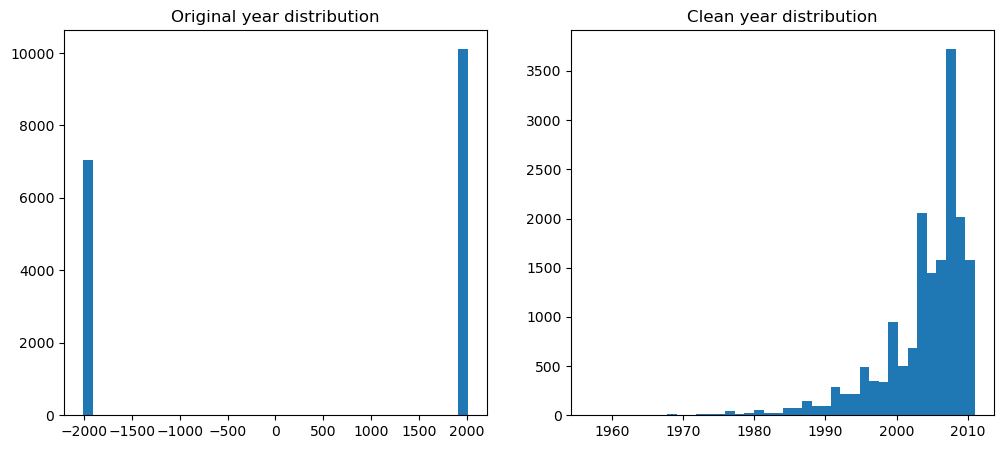

In [441]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].hist(df_original["pyear"], bins=40)
ax[0].set_title("Original year distribution")
ax[1].hist(df["pyear"], bins=40)
ax[1].set_title("Clean year distribution")
plt.show()

### Publication type distribution

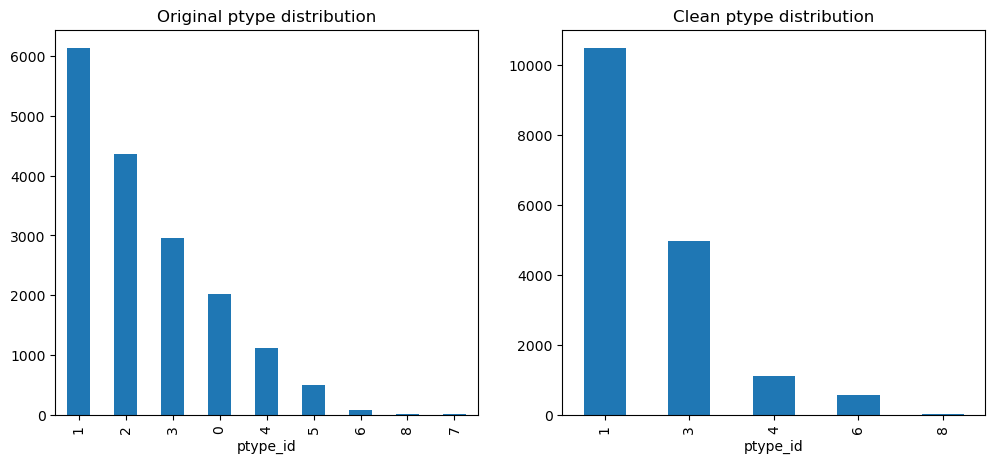

In [442]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

df_original["ptype_id"].value_counts().plot.bar(ax=ax[0])
ax[0].set_title("Original ptype distribution")
df["ptype_id"].value_counts().plot.bar(ax=ax[1])
ax[1].set_title("Clean ptype distribution")
plt.show()

### Missing venue names

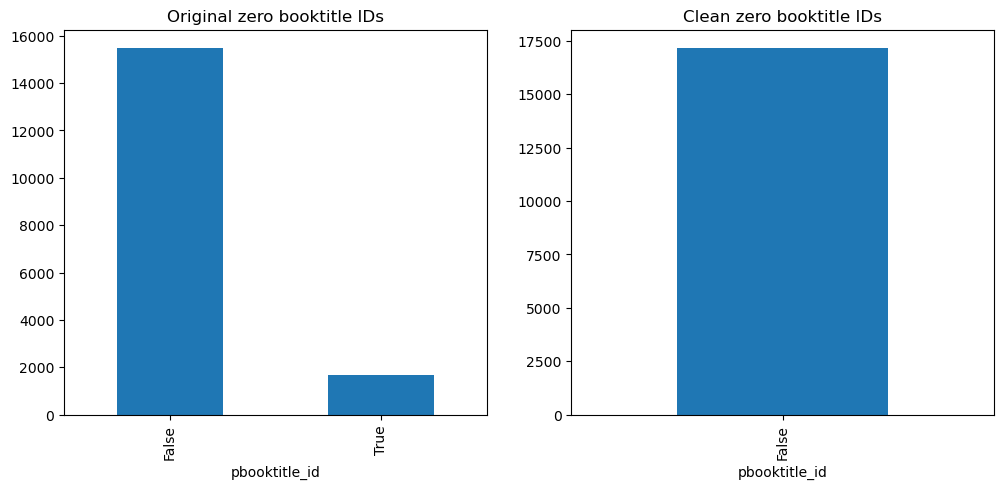

In [443]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

(df_original["pbooktitle_id"] == 0).value_counts().plot.bar(ax=ax[0])
ax[0].set_title("Original zero booktitle IDs")
(df["pbooktitle_id"] == 0).value_counts().plot.bar(ax=ax[1])
ax[1].set_title("Clean zero booktitle IDs")
plt.show()

## (Simple) feature engineering

We can start with feature enginnering now. As we know, the model should predict whether two papers are duplicates, so we should load our training data first and then use it to attach our cleaned df 

In [444]:
train = pd.read_csv("data/train.csv")
train.head()

,Unnamed: 0,key1,key2,label,partition
0,0,conf/prib/AhmedF07,journals/jcc/PatraS09,False,7
1,1,conf/vlsid/ChenCC95,journals/tcad/LuoCWCCW08,True,4
2,2,conf/prozess/Sun88,conf/isnn/SunZLCS07,True,8
3,3,conf/pricai/BeaumontTSM04,conf/icip/SattarAS08,False,5
4,4,conf/dft/SemiaoRVSTT07,conf/iolts/Rodriguez-IragoAVSTT05,True,7


Now we need to attach our dataframe for both papers by merging the DLBP table twice.

In [445]:
train_pairs = train.merge(
    df,
    left_on="key1",
    right_on="pkey",
    how="left"
)

train_pairs = train_pairs.merge(
    df,
    left_on="key2",
    right_on="pkey",
    how="left",
    suffixes=("_1", "_2")
)

train_pairs.columns

Index(['Unnamed: 0', 'key1', 'key2', 'label', 'partition_x', 'pauthor_1',
       'peditor_1', 'ptitle_1', 'pyear_1', 'paddress_1', 'ppublisher_1',
       'pseries_1', 'pid_1', 'pkey_1', 'ptype_id_1', 'pjournal_id_1',
       'pbooktitle_id_1', 'pjournalfull_id_1', 'pbooktitlefull_id_1',
       'partition_y', 'pauthor_2', 'peditor_2', 'ptitle_2', 'pyear_2',
       'paddress_2', 'ppublisher_2', 'pseries_2', 'pid_2', 'pkey_2',
       'ptype_id_2', 'pjournal_id_2', 'pbooktitle_id_2', 'pjournalfull_id_2',
       'pbooktitlefull_id_2', 'partition'],
      dtype='object')

Now each row contains information on both paper 1, paper 2 and the label.

### Similarity features for feature engineering

I will start with some of the most intuitive and simpler features for the feature matrix. Based on the performance I get on a baseline we can then decide which features to work on and which other features to add or drop.

### *Title similarity*

Probably the feature with the most potential, whether titles are similar is a great indicator of a duplicate entry. For now, for this we can use TF IDF and cosine similarity which is an industry standard and has been shown to perform well.

In [446]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words="english")
tfidf = vectorizer.fit_transform(df["ptitle"].fillna(""))
key_to_index = {k: i for i, k in enumerate(df["pkey"])}

def title_similarity(row):
    i = key_to_index.get(row["key1"])
    j = key_to_index.get(row["key2"])
    
    if i is None or j is None:
        return 0
    
    return cosine_similarity(tfidf[i], tfidf[j])[0][0]

train_pairs["title_sim"] = train_pairs.apply(title_similarity, axis=1)

Another feature we can use is whether the authors are the same. 

In [447]:
def author_jaccard(a1, a2):
    if pd.isna(a1) or pd.isna(a2):
        return 0
    
    s1 = set(a1.split("|"))
    s2 = set(a2.split("|"))
    
    return len(s1 & s2) / len(s1 | s2)

train_pairs["author_jaccard"] = train_pairs.apply(
    lambda x: author_jaccard(x["pauthor_1"], x["pauthor_2"]),
    axis=1
)

We can also compute the difference between the publication years of the 2 papers as another feature, based on the fact that papers that share the same year (or are closer in years) have a higher chance of being duplicates

In [448]:
train_pairs["year_diff"] = abs(train_pairs["pyear_1"] - train_pairs["pyear_2"])

Another feature we can use is whether the venues match

In [449]:
train_pairs["same_journal"] = (
    train_pairs["pjournal_id_1"] == train_pairs["pjournal_id_2"]
).astype(int)

train_pairs["same_booktitle"] = (
    train_pairs["pbooktitle_id_1"] == train_pairs["pbooktitle_id_2"]
).astype(int)

We can also check whether the publication is of the same type

In [450]:
train_pairs["same_ptype"] = (
    train_pairs["ptype_id_1"] == train_pairs["ptype_id_2"]
).astype(int)

### Building the feature matrix

Our final feature set is then:

In [451]:
features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "same_journal",
    "same_booktitle",
    "same_ptype"
]

Now we can build the feature matrix with our features:

In [452]:
X = train_pairs[features]
y = train_pairs["label"]

Let's check that the binary classes are balanced and there are no nan values:

In [453]:
X.head()
y.value_counts() 

label
False    4027
True     3945
Name: count, dtype: int64

In [454]:
X.isna().sum()

title_sim         0
author_jaccard    0
year_diff         0
same_journal      0
same_booktitle    0
same_ptype        0
dtype: int64

### Train/validation split

In [455]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2, # 80/20 split since it is standard
    stratify=y,
    random_state=42
)

### Baseline

To start we can train a simple logistic regression to keep as a baseline. 

In [456]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

We can evaluate the model with both accuracy and AUC.

In [457]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

preds = model.predict_proba(X_val)[:,1]

print("ROC:", roc_auc_score(y_val, preds))
print("Accuracy:", accuracy_score(y_val, preds.round()))
print("Precision:", precision_score(y_val, preds.round()))
print("Recall:", recall_score(y_val, preds.round()))
print("F1 Score:", f1_score(y_val, preds.round()))

ROC: 0.8851924885286838
Accuracy: 0.8463949843260188
Precision: 0.9927536231884058
Recall: 0.6945500633713562
F1 Score: 0.8173005219985086


This performance is already quite good for a baseline and our first try at feature engineering.

Lets check with features from our matrix are most relevant when identifying duplicates:

In [458]:
pd.Series(
    model.coef_[0],
    index=features
).sort_values(ascending=False)

author_jaccard    16.542693
title_sim          6.962045
same_booktitle     0.179120
same_ptype         0.146348
same_journal       0.089250
year_diff          0.021447
dtype: float64

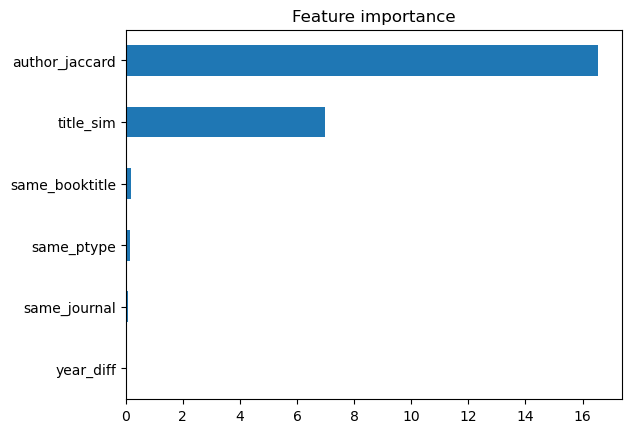

In [459]:
import matplotlib.pyplot as plt

pd.Series(
    model.coef_[0],
    index=features
).sort_values().plot(kind="barh")

plt.title("Feature importance")
plt.show()

My conclusion so far is this: this is not a bad result, but we can probably achieve higher performance if we work on the features more. The fact that authors similarity is more telling than title similarity is interesting. This could be because author names are much more unique than title words. We can try implementing a more robust way to check similarity, instead of TF-IDF and see if that improves performance. Year difference is pretty straightforward, as well as the others. Let's see what changes we can make to our features and up the performance of our baseline.

### 1st attempt at improving feature engineering 

Firstly, we can try and match, instead of the whole author list, the first author in the list. This could be a more unique identifier of same author lists (therefore a duplicate).

In [460]:
def first_author(a):
    if pd.isna(a):
        return ""
    return a.split("|")[0]

train_pairs["first_author_match"] = (
    train_pairs["pauthor_1"].apply(first_author) ==
    train_pairs["pauthor_2"].apply(first_author)
).astype(int)

We can also calculate the difference in lenght across titles, which might be a good combination with title similarity.

In [461]:
train_pairs["title_len_diff"] = (
    train_pairs["ptitle_1"].str.len() -
    train_pairs["ptitle_2"].str.len()
).abs()

We can also try and match words that titles share

In [462]:
def shared_words(t1, t2):
    if pd.isna(t1) or pd.isna(t2):
        return 0

    s1 = set(t1.lower().split())
    s2 = set(t2.lower().split())

    return len(s1 & s2)

train_pairs["shared_title_words"] = train_pairs.apply(
    lambda x: shared_words(x["ptitle_1"], x["ptitle_2"]),
    axis=1
)

Instead of calculating year difference, we can match the year to see if it is the same.

In [463]:
train_pairs["same_year"] = (
    train_pairs["pyear_1"] == train_pairs["pyear_2"]
).astype(int)

Lastly we can calculate how many authors in total each publication contains, and calculate the difference between the two papers.

In [464]:
train_pairs["author_count_1"] = train_pairs["pauthor_1"].fillna("").str.count("\|") + 1
train_pairs["author_count_2"] = train_pairs["pauthor_2"].fillna("").str.count("\|") + 1

train_pairs["author_count_diff"] = (
    train_pairs["author_count_1"] - train_pairs["author_count_2"]
).abs()

<>:1: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:1: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
/var/folders/0g/15db9dkj6sqc0rd5wphd31400000gn/T/ipykernel_94915/3438469511.py:1: SyntaxWarning: invalid escape sequence '\|'
  train_pairs["author_count_1"] = train_pairs["pauthor_1"].fillna("").str.count("\|") + 1
/var/folders/0g/15db9dkj6sqc0rd5wphd31400000gn/T/ipykernel_94915/3438469511.py:2: SyntaxWarning: invalid escape sequence '\|'
  train_pairs["author_count_2"] = train_pairs["pauthor_2"].fillna("").str.count("\|") + 1


We now build the hopefully improved feature matrix again

In [465]:
features_new = [
    "title_sim",
    "first_author_match",
    "shared_title_words",
    "title_len_diff",
    "same_year",
    "author_count_diff",
    "same_journal",
    "same_booktitle",
    "same_ptype"
]

In [466]:
train_pairs.columns

Index(['Unnamed: 0', 'key1', 'key2', 'label', 'partition_x', 'pauthor_1',
       'peditor_1', 'ptitle_1', 'pyear_1', 'paddress_1', 'ppublisher_1',
       'pseries_1', 'pid_1', 'pkey_1', 'ptype_id_1', 'pjournal_id_1',
       'pbooktitle_id_1', 'pjournalfull_id_1', 'pbooktitlefull_id_1',
       'partition_y', 'pauthor_2', 'peditor_2', 'ptitle_2', 'pyear_2',
       'paddress_2', 'ppublisher_2', 'pseries_2', 'pid_2', 'pkey_2',
       'ptype_id_2', 'pjournal_id_2', 'pbooktitle_id_2', 'pjournalfull_id_2',
       'pbooktitlefull_id_2', 'partition', 'title_sim', 'author_jaccard',
       'year_diff', 'same_journal', 'same_booktitle', 'same_ptype',
       'first_author_match', 'title_len_diff', 'shared_title_words',
       'same_year', 'author_count_1', 'author_count_2', 'author_count_diff'],
      dtype='object')

Then we build the training matrix again

In [467]:
train_pairs.drop(columns=["title_jaccard"], inplace=True, errors="ignore")

In [468]:
X = train_pairs.loc[:, features_new].copy()
y = train_pairs["label"]

In [469]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [470]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [471]:
preds = model.predict_proba(X_val)[:,1]
print("ROC:", roc_auc_score(y_val, preds))
print("Accuracy:", accuracy_score(y_val, preds.round()))
print("Precision:", precision_score(y_val, preds.round()))
print("Recall:", recall_score(y_val, preds.round()))
print("F1 Score:", f1_score(y_val, preds.round()))

ROC: 0.749977198891709
Accuracy: 0.7009404388714734
Precision: 0.8627906976744186
Recall: 0.47021546261089986
F1 Score: 0.6086956521739131


In [472]:
pd.Series(
    model.coef_[0],
    index=features_new
).sort_values(ascending=False)

title_sim             8.228383
first_author_match    4.542499
same_booktitle        0.275675
same_ptype            0.214729
shared_title_words    0.159172
same_journal          0.143836
same_year             0.034092
title_len_diff       -0.000906
author_count_diff    -0.069077
dtype: float64

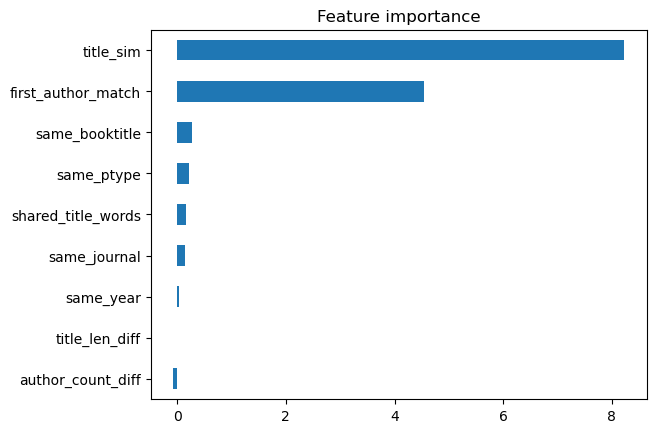

In [473]:
import matplotlib.pyplot as plt

pd.Series(
    model.coef_[0],
    index=features_new
).sort_values().plot(kind="barh")

plt.title("Feature importance")
plt.show()

Well, clearly that did not help. Our previous implementaitons of these features worked much better. The biggest takeaway is that we need to match the entire author list isntead of only the first author to improve performance (which makes sense). Title similarity is now the strongest feature to identify duplicate but this is because of the author implementation. The bottom 4 features, we can drop since they do not add any value to the model at all. 

### 2nd attempt at improving feature engineering

One last try with the title computation, we can try and see if using Jaccard helps along with the original features we had from our first implementation:

In [474]:
def title_jaccard(t1,t2):
    s1=set(t1.split())
    s2=set(t2.split())
    return len(s1&s2)/max(len(s1|s2),1)

train_pairs["title_jaccard"]=train_pairs.apply(
    lambda x:title_jaccard(x["ptitle_1"],x["ptitle_2"]),
    axis=1
)

In [475]:
features_new_new= [
    "title_jaccard",
    "author_jaccard",
    "year_diff",
    "same_journal",
    "same_booktitle",
    "same_ptype"
]

In [476]:
X = train_pairs.loc[:, features_new_new].copy()
y = train_pairs["label"]
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [477]:
print(len(features_new_new))
print(X.shape)

6
(7972, 6)


In [478]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [479]:
preds = model.predict_proba(X_val)[:,1]
print("ROC:", roc_auc_score(y_val, preds))
print("Accuracy:", accuracy_score(y_val, preds.round()))
print("Precision:", precision_score(y_val, preds.round()))
print("Recall:", recall_score(y_val, preds.round()))
print("F1 Score:", f1_score(y_val, preds.round()))

ROC: 0.8671151408793993
Accuracy: 0.8307210031347962
Precision: 0.9961759082217974
Recall: 0.6603295310519645
F1 Score: 0.7942073170731707


In [480]:
pd.Series(
    model.coef_[0],
    index=features_new_new
).sort_values(ascending=False)

author_jaccard    16.805164
title_jaccard      4.178877
same_booktitle     0.172458
same_ptype         0.155452
same_journal       0.090365
year_diff          0.018090
dtype: float64

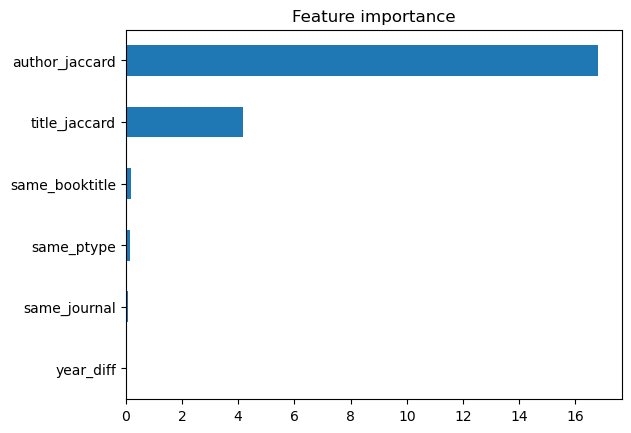

In [481]:
import matplotlib.pyplot as plt

pd.Series(
    model.coef_[0],
    index=features_new_new
).sort_values().plot(kind="barh")

plt.title("Feature importance")
plt.show()

Conclusion: calculating title similarity with jaccard actually decreases performance by a bit. We should then keep out title_sim variable for this since our original implementation actually gave us the highest performance of all. So far, the best feature list we have found is:
features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "same_journal",
    "same_booktitle",
    "same_ptype"
]


In general, auhtor lists are the most important when checking for duplicates.Then titles, then venue info and then year. The additional features really did not add much, likely because they correlated with similar versions of themselves that we already had implemented so the improvements were not significant. At this point we should try to use an optimizer to find us the best combination of features out of all the ones we just created.

### Search for best features with L1 regularization

We can try using L1 regularization to find the best features combinations with all the features we computed so far.

In [482]:
from sklearn.linear_model import LogisticRegression

all_features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "same_journal",
    "same_booktitle",
    "same_ptype",
    "first_author_match",
    "shared_title_words",
    "title_len_diff",
    "same_year",
    "author_count_diff",
    "title_jaccard"
]

X = train_pairs[all_features].fillna(0)

model_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

model_l1.fit(X, y)
model.fit(train_pairs[all_features].fillna(0), y)

LogisticRegression(max_iter=1000)

In [483]:
coef = pd.Series(model_l1.coef_[0], index=all_features)
coef.sort_values(ascending=False)

author_jaccard        46.627682
title_sim             11.071856
same_booktitle         0.251769
same_ptype             0.142328
same_journal           0.052154
shared_title_words     0.028996
year_diff              0.027158
first_author_match     0.000000
title_jaccard          0.000000
title_len_diff        -0.001589
author_count_diff     -0.057611
same_year             -0.192325
dtype: float64

In [484]:
selected_features = coef[coef != 0].index.tolist()
selected_features

['title_sim',
 'author_jaccard',
 'year_diff',
 'same_journal',
 'same_booktitle',
 'same_ptype',
 'shared_title_words',
 'title_len_diff',
 'same_year',
 'author_count_diff']

<Axes: >

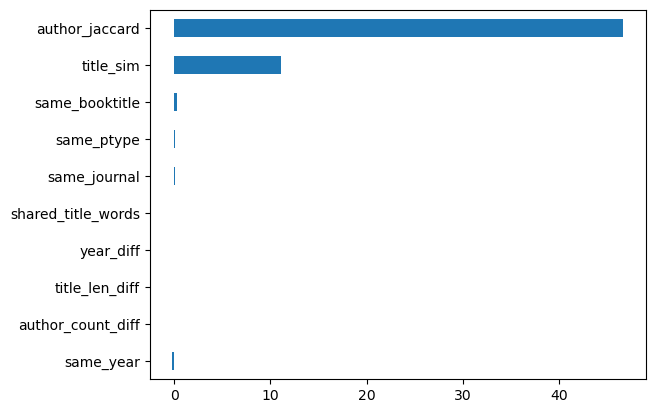

In [485]:
coef[coef != 0].sort_values().plot(kind="barh")

In [486]:
y_pred = model_l1.predict(X)
y_prob = model_l1.predict_proba(X)[:, 1]

In [487]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y, y_pred))
print("ROC AUC:", roc_auc_score(y, y_prob))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1 Score:", f1_score(y, y_pred))

Accuracy: 0.822002007024586
ROC AUC: 0.8597504550242769
Precision: 0.9670857988165681
Recall: 0.6628643852978454
F1 Score: 0.7865844487892916


As we can see, L1 regularization does not improve the feature list, if anything it achieved slighly lower performance than our original implementaiton (which had ROC AUC ≈ 0.885, Accuracy ≈ 0.846). However it did confirm that author_jaccard and title_sim are the most important features.

### Baseline decision tree classifier

As another baseline it is good to have a tree-based method since most likely our main model will be tree-based as well. I will train a simple decision tree with the original feature list since it has proven most successful thus far.

In [488]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "same_journal",
    "same_booktitle",
    "same_ptype"
]

X = train_pairs[features].fillna(0)
y = train_pairs["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

In [489]:
pred = dt.predict(X_val)
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

       False       0.78      0.97      0.86       806
        True       0.96      0.72      0.82       789

    accuracy                           0.85      1595
   macro avg       0.87      0.85      0.84      1595
weighted avg       0.87      0.85      0.84      1595



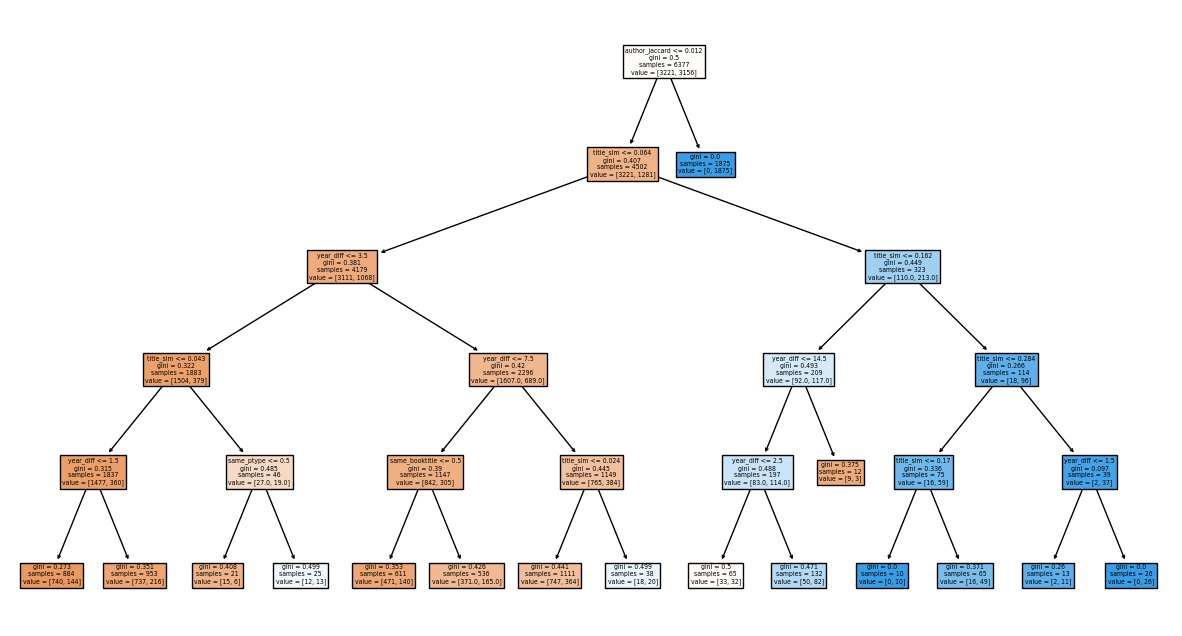

In [490]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,8))
plot_tree(dt, feature_names=features, filled=True)
plt.show()

### Summary

Highest performance so far achieved with the original `features` implementation:

ROC: 0.8851893435482298

Accuracy: 0.8463949843260188

Precision: 0.9927536231884058

Recall: 0.6945500633713562

F1 Score: 0.8173005219985086

with Logistic Regression

Most important features currently:

author_jaccard

title_sim

same_book_title

same_ptype

same_journal


## TO DOs (some to take into considerations would be nice-to-haves, others are things we probably must do)

1. Could: Improve title similarity feature --> current model relies heavily on author_jaccard and title similarity, so improving title matching could increase performance. Some things I thought of: n-gram based similarity, better text preprocessing (remove punctuation, normalize spacing), and if allowed probbaly our best bet is SBERT which is a deep learning framework widely used in these applications
2. Could: explore other features --> frankly i cannot think of many others but it's worth a shot (not necessarily completely new features but variations of exiswting ones / improving the current implementations)
3. Could: trying other types of feature list optimization 
3. Should: then hyper parameter tuning with GridSearch 
4. Must: Try different models --> so far i only tested features on simple logistic regression and decision tree. We shoudl try other tree-based methods, random forest and eventually XGBoost. 
5. Should: other performance metrics --> so far I mostly did not compute confusion matrix, but could be helpful to see exactly what the model is struggling with since it looks like our precision is almost perfect but our recall is quite low --> and then think of ways to balance this out

## Random Forest Classifier

In [491]:
from sklearn.ensemble import RandomForestClassifier

features = [
    "title_sim",
    "author_jaccard",
    "year_diff",
    "same_journal",
    "same_booktitle",
    "same_ptype"
]

X = train_pairs[features].fillna(0)
y = train_pairs["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [492]:
preds_rf = rf.predict_proba(X_val)[:, 1]

print("Random Forest Results:")
print(f"  ROC AUC:   {roc_auc_score(y_val, preds_rf):.4f}")
print(f"  Accuracy:  {accuracy_score(y_val, preds_rf.round()):.4f}")
print(f"  Precision: {precision_score(y_val, preds_rf.round()):.4f}")
print(f"  Recall:    {recall_score(y_val, preds_rf.round()):.4f}")
print(f"  F1 Score:  {f1_score(y_val, preds_rf.round()):.4f}")

Random Forest Results:
  ROC AUC:   0.8740
  Accuracy:  0.8339
  Precision: 0.9281
  Recall:    0.7199
  F1 Score:  0.8108


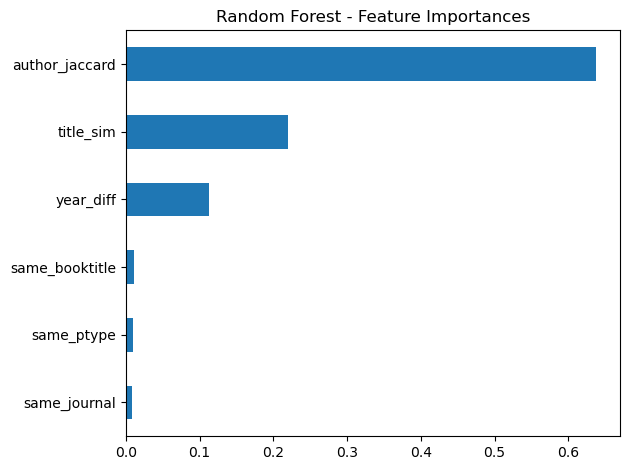

In [493]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind="barh")
plt.title("Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

In [494]:
# retrain on the full training set
rf_full = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X, y)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [495]:
def title_sim(row, tfidf_matrix, key_index):
    i = key_index.get(row["key1"])
    j = key_index.get(row["key2"])
    if i is None or j is None:
        return 0
    return cosine_similarity(tfidf_matrix[i], tfidf_matrix[j])[0][0]

def compute_features(pairs_df, dblp_df, tfidf_matrix, key_index, feature_list):
    merged = pairs_df.merge(dblp_df, left_on="key1", right_on="pkey", how="left")
    merged = merged.merge(dblp_df, left_on="key2", right_on="pkey", how="left", suffixes=("_1", "_2"))

    merged["title_sim"] = merged.apply(title_sim, axis=1, tfidf_matrix=tfidf_matrix, key_index=key_index)
    merged["author_jaccard"] = merged.apply(lambda x: author_jaccard(x["pauthor_1"], x["pauthor_2"]), axis=1)
    merged["year_diff"] = (merged["pyear_1"] - merged["pyear_2"]).abs()
    merged["same_journal"] = (merged["pjournal_id_1"] == merged["pjournal_id_2"]).astype(int)
    merged["same_booktitle"] = (merged["pbooktitle_id_1"] == merged["pbooktitle_id_2"]).astype(int)
    merged["same_ptype"] = (merged["ptype_id_1"] == merged["ptype_id_2"]).astype(int)

    return merged[feature_list].fillna(0)

In [496]:
val_pairs = pd.read_csv("data/validation_hidden.csv", index_col=0)
test_pairs = pd.read_csv("data/test_hidden.csv", index_col=0)

X_val_submit = compute_features(val_pairs, df, tfidf, key_to_index, features)
X_test_submit = compute_features(test_pairs, df, tfidf, key_to_index, features)

val_pairs["label"] = rf_full.predict(X_val_submit)
test_pairs["label"] = rf_full.predict(X_test_submit)

val_pairs[["key1", "key2", "label"]].to_csv("validation_predictions.csv", index=False)
test_pairs[["key1", "key2", "label"]].to_csv("test_predictions.csv", index=False)

print(f"Validation predictions: {val_pairs['label'].value_counts().to_dict()}")
print(f"Test predictions:       {test_pairs['label'].value_counts().to_dict()}")

Validation predictions: {False: 630, True: 364}
Test predictions:       {False: 633, True: 401}


## XGBoost Classifier

XGBoost uses gradient boosting which should better capture non-linear feature interactions compared to logistic regression and random forest.

In [497]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [498]:
preds_xgb = xgb.predict_proba(X_val)[:, 1]

print("XGBoost Results:")
print(f"  ROC AUC:   {roc_auc_score(y_val, preds_xgb):.4f}")
print(f"  Accuracy:  {accuracy_score(y_val, preds_xgb.round()):.4f}")
print(f"  Precision: {precision_score(y_val, preds_xgb.round()):.4f}")
print(f"  Recall:    {recall_score(y_val, preds_xgb.round()):.4f}")
print(f"  F1 Score:  {f1_score(y_val, preds_xgb.round()):.4f}")

XGBoost Results:
  ROC AUC:   0.8856
  Accuracy:  0.8470
  Precision: 0.9674
  Recall:    0.7148
  F1 Score:  0.8222


same_booktitle    0.004107
same_ptype        0.004352
same_journal      0.004419
year_diff         0.006144
title_sim         0.007507
author_jaccard    0.973472
dtype: float32


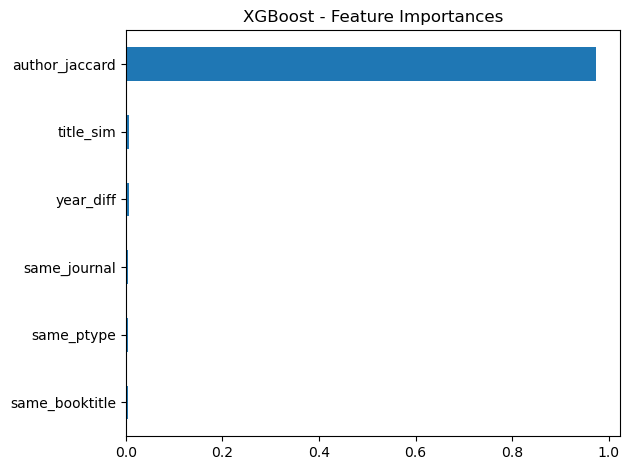

In [503]:
importances_xgb = pd.Series(xgb.feature_importances_, index=features).sort_values()
importances_xgb.plot(kind="barh")
print(importances_xgb)
plt.title("XGBoost - Feature Importances")
plt.tight_layout()
plt.show()

### XGBoost predictions for leaderboard submission

Retrain on the full training set and generate predictions.

In [500]:
xgb_full = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_full.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [501]:
val_pairs = pd.read_csv("data/validation_hidden.csv", index_col=0)
test_pairs = pd.read_csv("data/test_hidden.csv", index_col=0)

X_val_submit = compute_features(val_pairs, df, tfidf, key_to_index, features)
X_test_submit = compute_features(test_pairs, df, tfidf, key_to_index, features)

val_pairs["label"] = xgb_full.predict(X_val_submit)
test_pairs["label"] = xgb_full.predict(X_test_submit)

val_pairs[["key1", "key2", "label"]].to_csv("validation_predictions.csv", index=False)
test_pairs[["key1", "key2", "label"]].to_csv("test_predictions.csv", index=False)

print(f"Validation predictions: {val_pairs['label'].value_counts().to_dict()}")
print(f"Test predictions:       {test_pairs['label'].value_counts().to_dict()}")

Validation predictions: {0: 641, 1: 353}
Test predictions:       {0: 647, 1: 387}
